This notebook performs Exploratory Data Analysis (EDA) on a Kaggle-sourced Spam & Ham email dataset. The dataset can be accessed on Kaggle using the following link: https://www.kaggle.com/datasets/meruvulikith/190k-spam-ham-email-dataset-for-classification/data


In [1]:
# Mounting Google Drive to access the dataset. Alternatively, you may upload the dataset directly from your local storage.

from google.colab import drive
drive.mount('/content/drive')

# Change this according to where your dataset is stored.
dataset_path ="/content/drive/MyDrive/Spam-Ham Dataset/spam_Emails_data.csv"

Mounted at /content/drive


In [2]:
# Import all required packages for the EDA

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import os
import re

# Create assets folder and set plot DPI
EDA_PLOT_DIR = "/content/assets/eda_plots"
os.makedirs(EDA_PLOT_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 150

print("EDA plots folder created at:", EDA_PLOT_DIR)

EDA plots folder created at: /content/assets/eda_plots


In [3]:
# Load the dataset and perform basic inspection

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("Shape of dataset:", df.shape)
print("First few rows of dataset:")
print(df.head())

Dataset loaded successfully.
Shape of dataset: (193852, 2)
First few rows of dataset:
  label                                               text
0  Spam  viiiiiiagraaaa\nonly for the ones that want to...
1   Ham  got ice thought look az original message ice o...
2  Spam  yo ur wom an ne eds an escapenumber in ch ma n...
3  Spam  start increasing your odds of success & live s...
4   Ham  author jra date escapenumber escapenumber esca...


In [4]:
# Check for missing values & duplicates

print("Missing values in the dataset:", df.isnull().sum())
print("Duplicate rows in the dataset:", df.duplicated().sum())

Missing values in the dataset: label    0
text     2
dtype: int64
Duplicate rows in the dataset: 0


Class distribution:
label
Ham     102160
Spam     91692
Name: count, dtype: int64


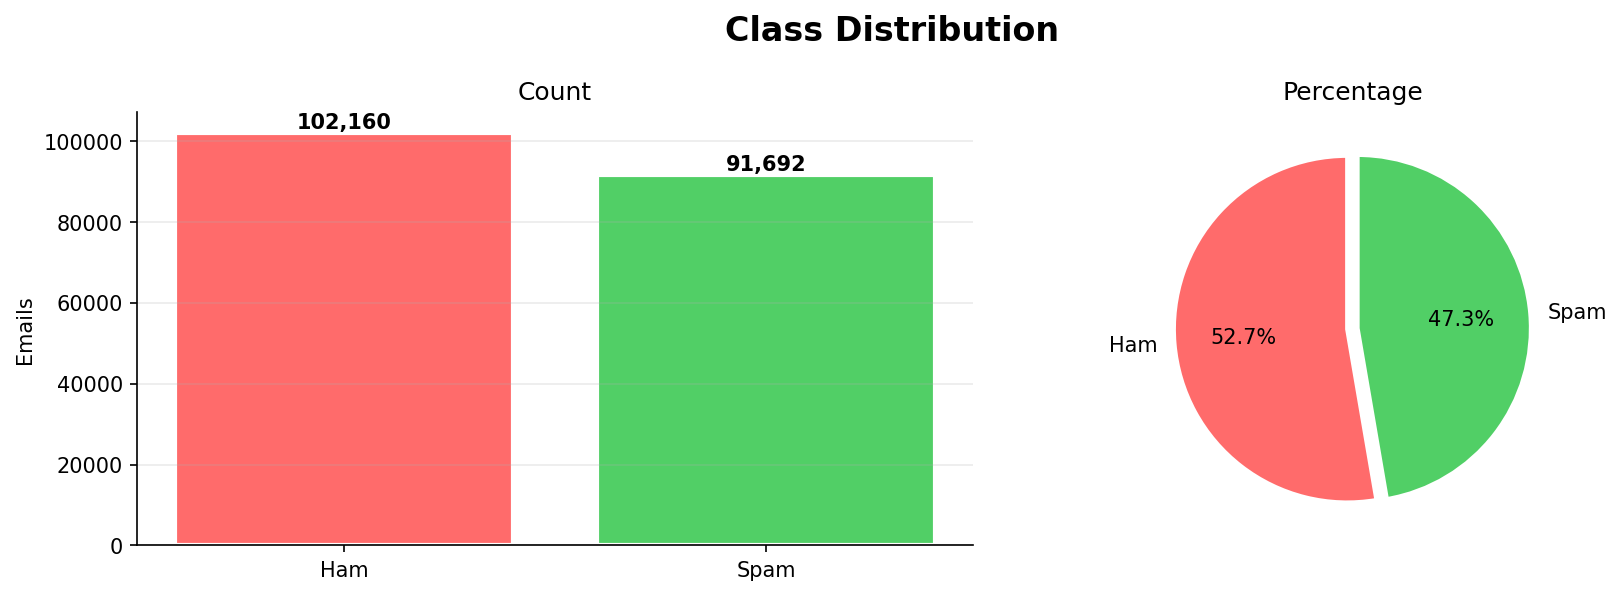

In [5]:
# Class distribution.
# Ideally a classification dataset should be near balanced.

counts = df["label"].value_counts()
os.makedirs("../assets/eda_plots", exist_ok=True)

colors = ["#ff6b6b", "#51cf66"]

print("Class distribution:")
print(counts)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Class Distribution", fontsize=16, fontweight="bold")

# Bar chart
bars = axes[0].bar(counts.index, counts.values, color=colors, edgecolor="white", linewidth=2)
axes[0].set_title("Count")
axes[0].set_ylabel("Emails")
axes[0].grid(axis="y", alpha=0.25)
axes[0].spines[["top", "right"]].set_visible(False)

for bar in bars:
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(bar.get_height()):,}",
        ha="center",
        va="bottom",
        fontweight="bold"
    )

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    colors=colors,
    startangle=90,
    explode=[0.03] * len(counts),
    wedgeprops={"edgecolor": "white", "linewidth": 2}
)
axes[1].set_title("Percentage")

plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOT_DIR, "class_distribution.png"))
plt.show()

In [6]:
# Analysis of email length distribution across spam and ham emails

df["char_count"]  = df["text"].str.len()
df["word_count"]  = df["text"].str.split().str.len()

print(df.groupby("label")[["char_count", "word_count"]].describe().round(1))

      char_count                                                          \
           count    mean      std  min    25%    50%     75%         max   
label                                                                      
Ham     102159.0  2169.7  36562.7  1.0  417.0  950.0  1968.0  11510306.0   
Spam     91691.0  1415.1   2368.0  1.0  309.0  675.0  1570.0    144087.0   

      word_count                                                     
           count   mean     std  min   25%    50%    75%        max  
label                                                                
Ham     102159.0  334.6  5047.1  1.0  65.0  149.0  311.0  1585483.0  
Spam     91691.0  210.8   337.9  1.0  47.0  106.0  239.0    25393.0  


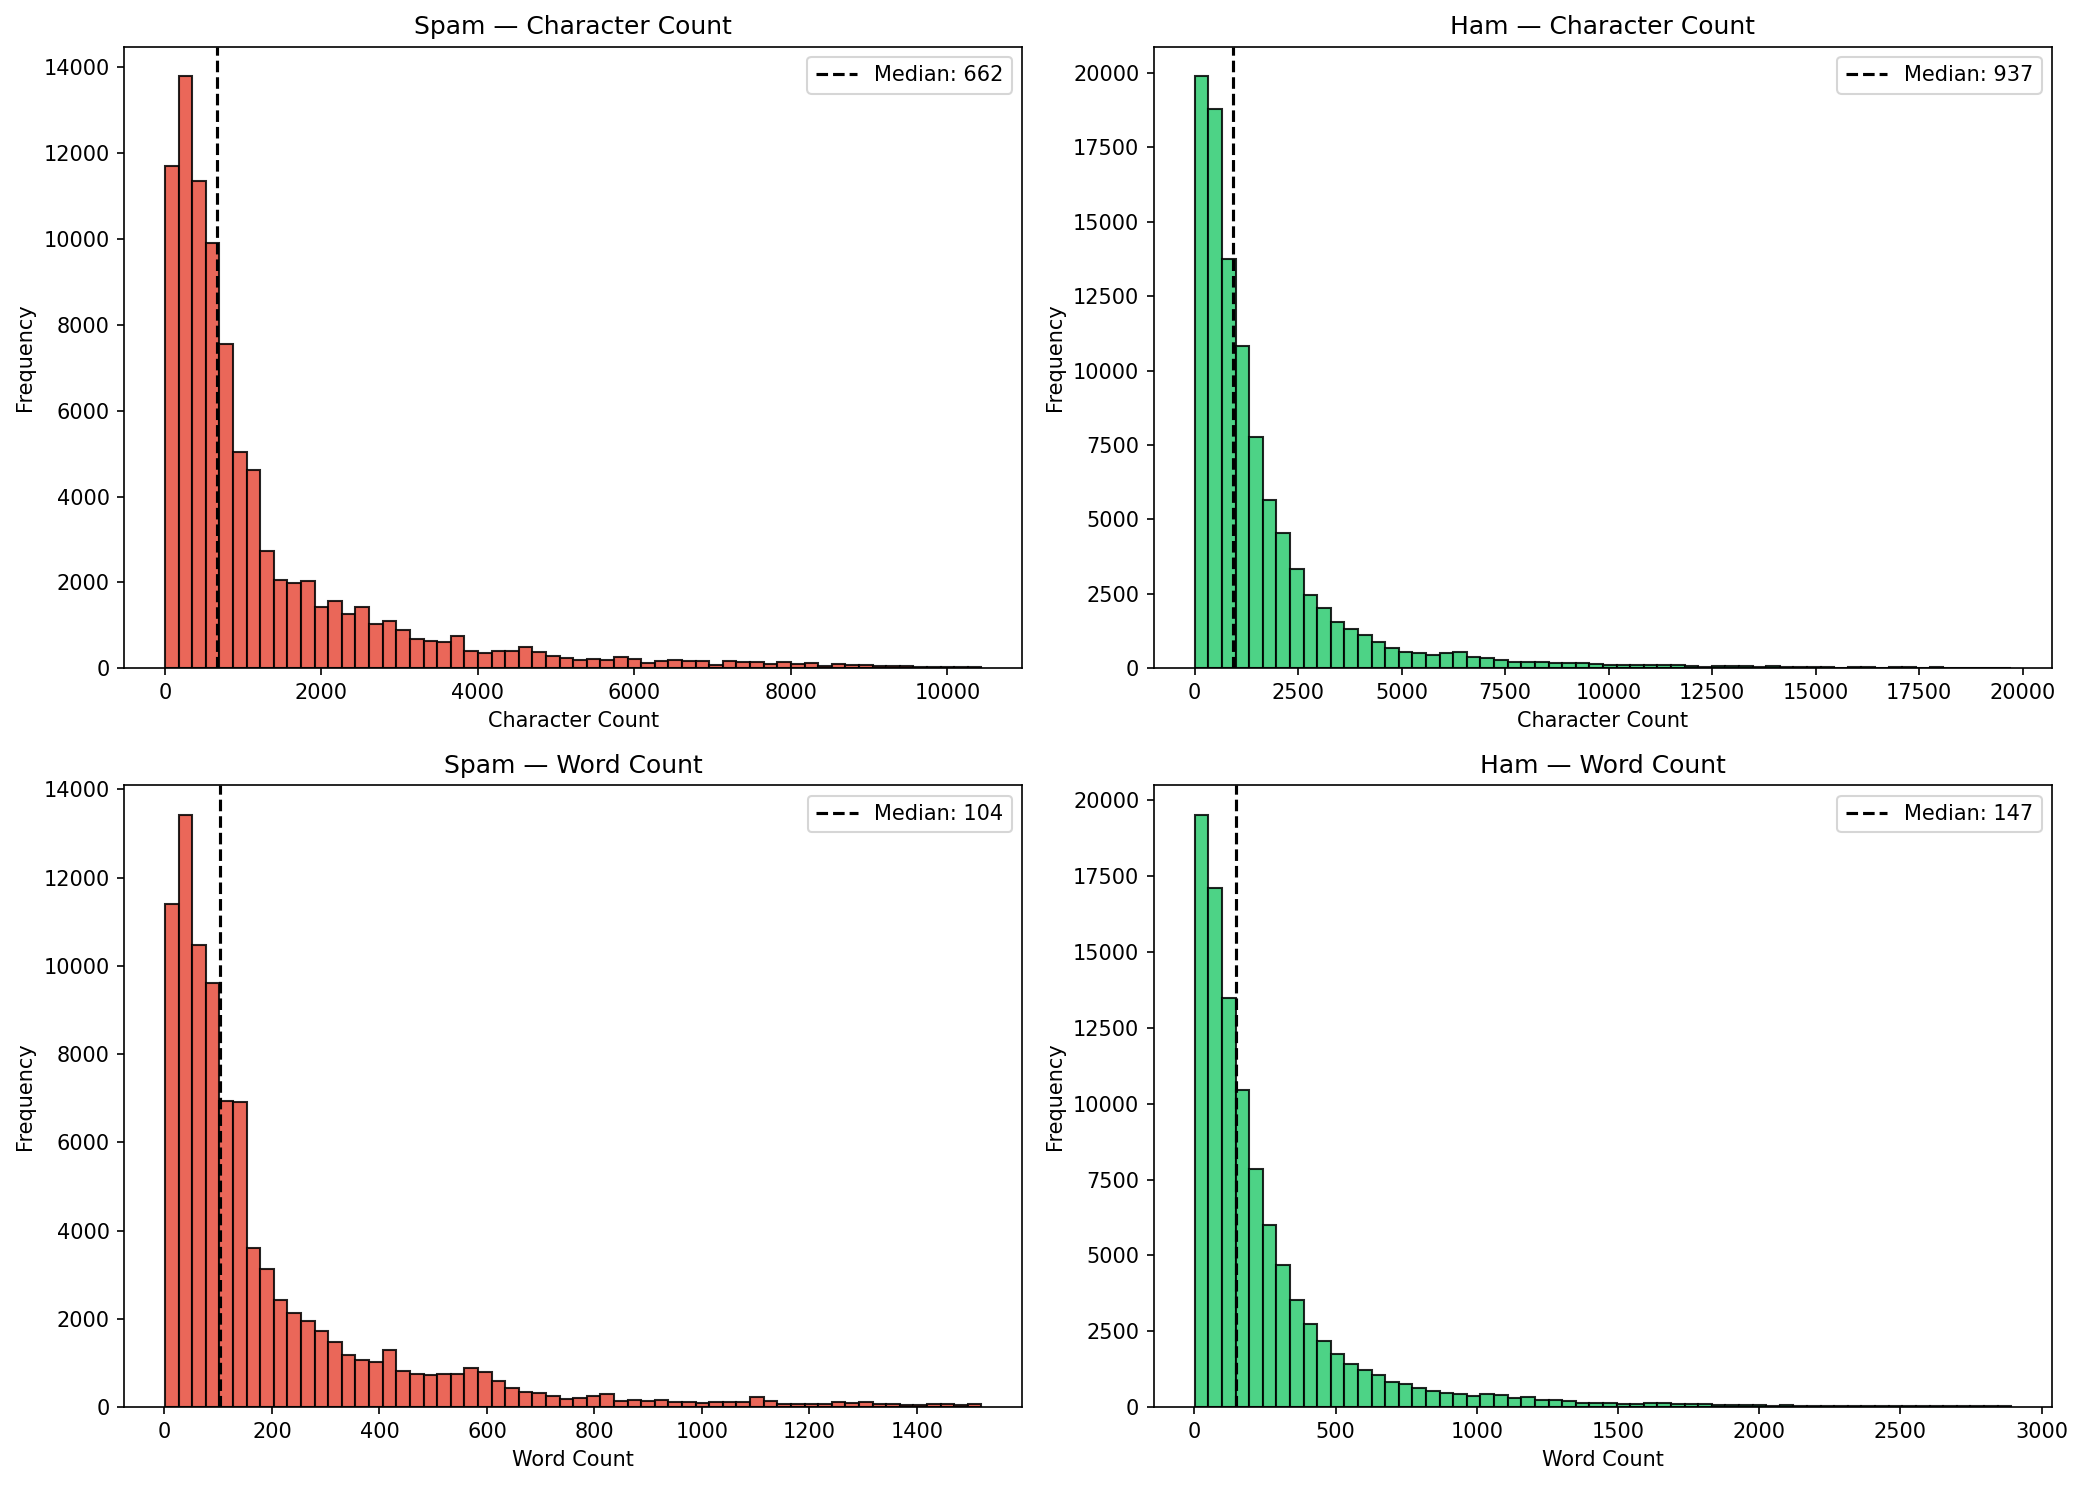

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, (col, title) in enumerate([("char_count", "Character Count"),
                                    ("word_count",  "Word Count")]):
    for j, (label, color) in enumerate([("Spam", "#e74c3c"), ("Ham", "#2ecc71")]):
        ax = axes[i][j]
        subset = df[df["label"] == label][col]

        # Cap the outliers for readability

        subset = subset[subset < subset.quantile(0.99)]
        ax.hist(subset, bins=60, color=color, edgecolor="black", alpha=0.85)
        ax.set_title(f"{label} — {title}")
        ax.set_xlabel(title)
        ax.set_ylabel("Frequency")
        ax.axvline(subset.median(), color="black", linestyle="--", label=f"Median: {subset.median():.0f}")
        ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOT_DIR, "length_distribution.png"))
plt.show()

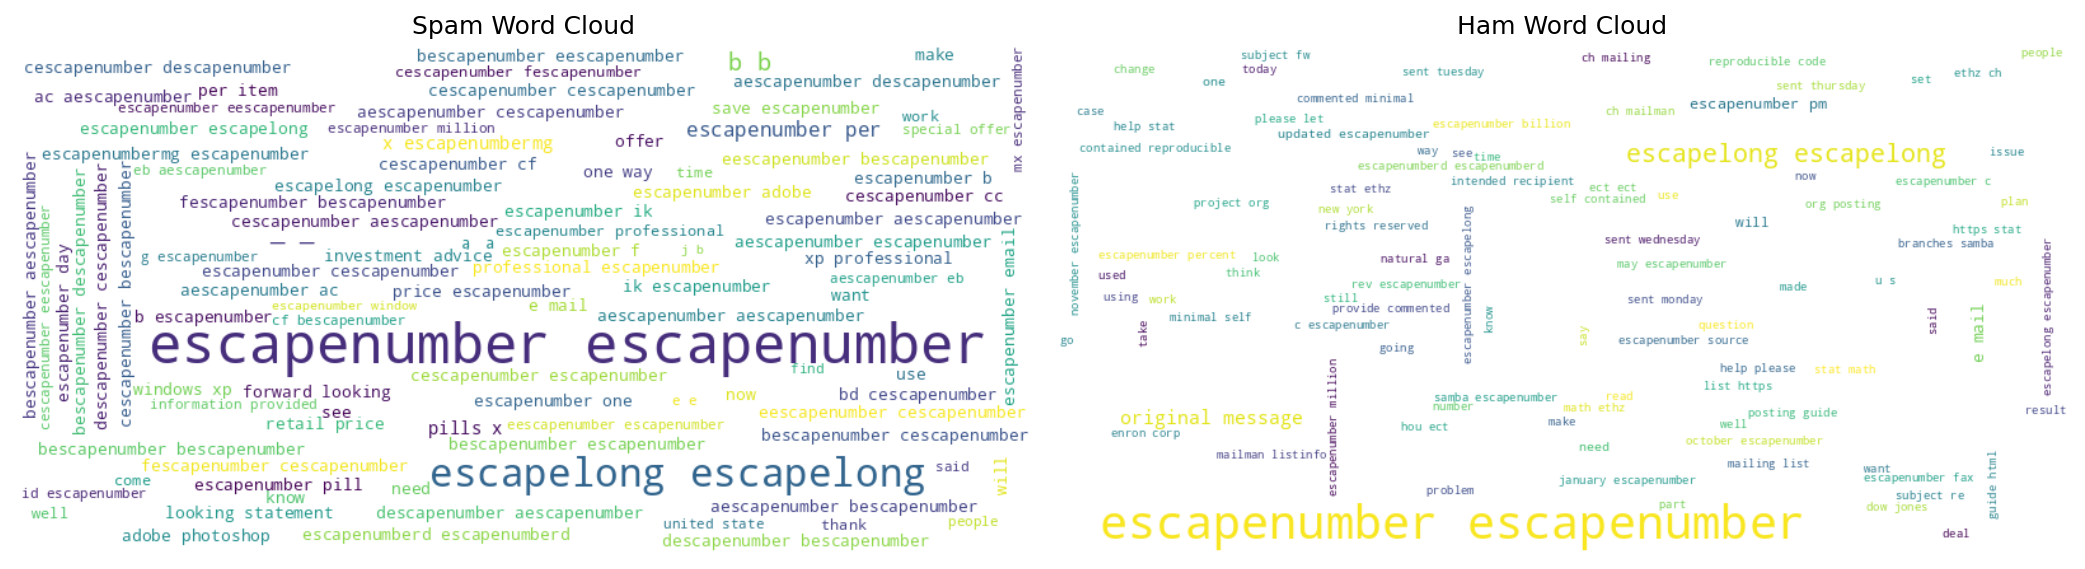

In [8]:
# Word Cloud
# Make sure WordCloud is installed

!pip install wordcloud -q

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Make sure text column is string and labels are clean
df["label"] = df["label"].astype(str).str.strip()
df["text"] = df["text"].astype(str)

# Separate Spam and Ham text
spam_text = " ".join(df[df["label"] == "Spam"]["text"])
ham_text = " ".join(df[df["label"] == "Ham"]["text"])

# Create word clouds
spam_cloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(spam_text)

ham_cloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(ham_text)

# Display both
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(spam_cloud, interpolation="bilinear")
plt.title("Spam Word Cloud")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(ham_cloud, interpolation="bilinear")
plt.title("Ham Word Cloud")
plt.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOT_DIR, "word_cloud.png"))
plt.show()

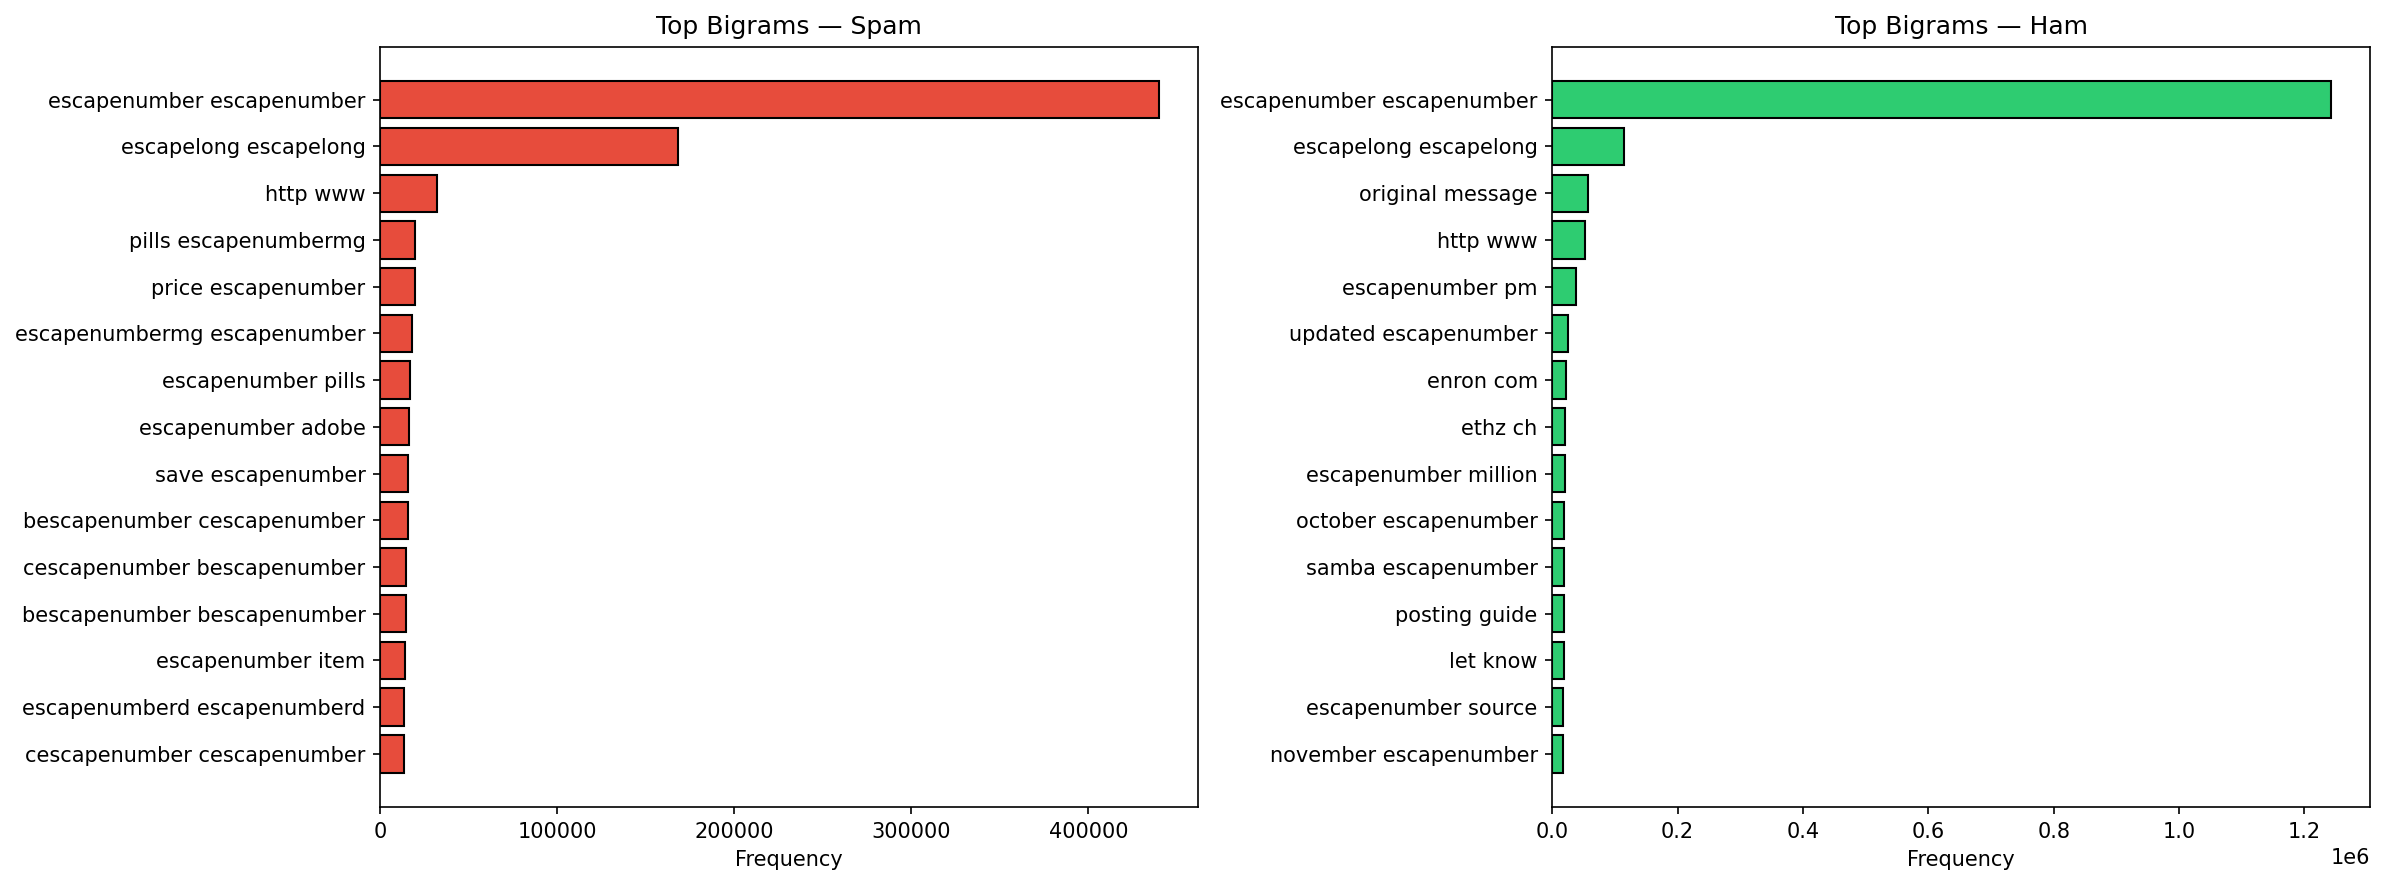

In [9]:
# Top Bigrams
# Single words give frequency. Bigrams (two-word pairs) reveal common phrases specific to spam or ham.

from sklearn.feature_extraction.text import CountVectorizer

def get_top_ngrams(df, label, n=2, top=15):
    corpus = df[df["label"] == label]["text"].str.lower()
    vec = CountVectorizer(ngram_range=(n, n), stop_words="english", max_features=10000)
    bow = vec.fit_transform(corpus)
    freqs = bow.sum(axis=0).A1
    vocab = vec.get_feature_names_out()
    return sorted(zip(vocab, freqs), key=lambda x: x[1], reverse=True)[:top]

spam_bigrams = get_top_ngrams(df, "Spam")
ham_bigrams  = get_top_ngrams(df, "Ham")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, bigrams, label, color in zip(axes,
                                      [spam_bigrams, ham_bigrams],
                                      ["Spam", "Ham"],
                                      ["#e74c3c", "#2ecc71"]):
    phrases, counts = zip(*bigrams)
    ax.barh(phrases[::-1], counts[::-1], color=color, edgecolor="black")
    ax.set_title(f"Top Bigrams — {label}")
    ax.set_xlabel("Frequency")

plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOT_DIR, "bigrams.png"))
plt.show()

       has_url  has_number  exclaim_count  dollar_count
label                                                  
Ham      0.311       0.155          0.097         0.161
Spam     0.486       0.121          0.257         0.206


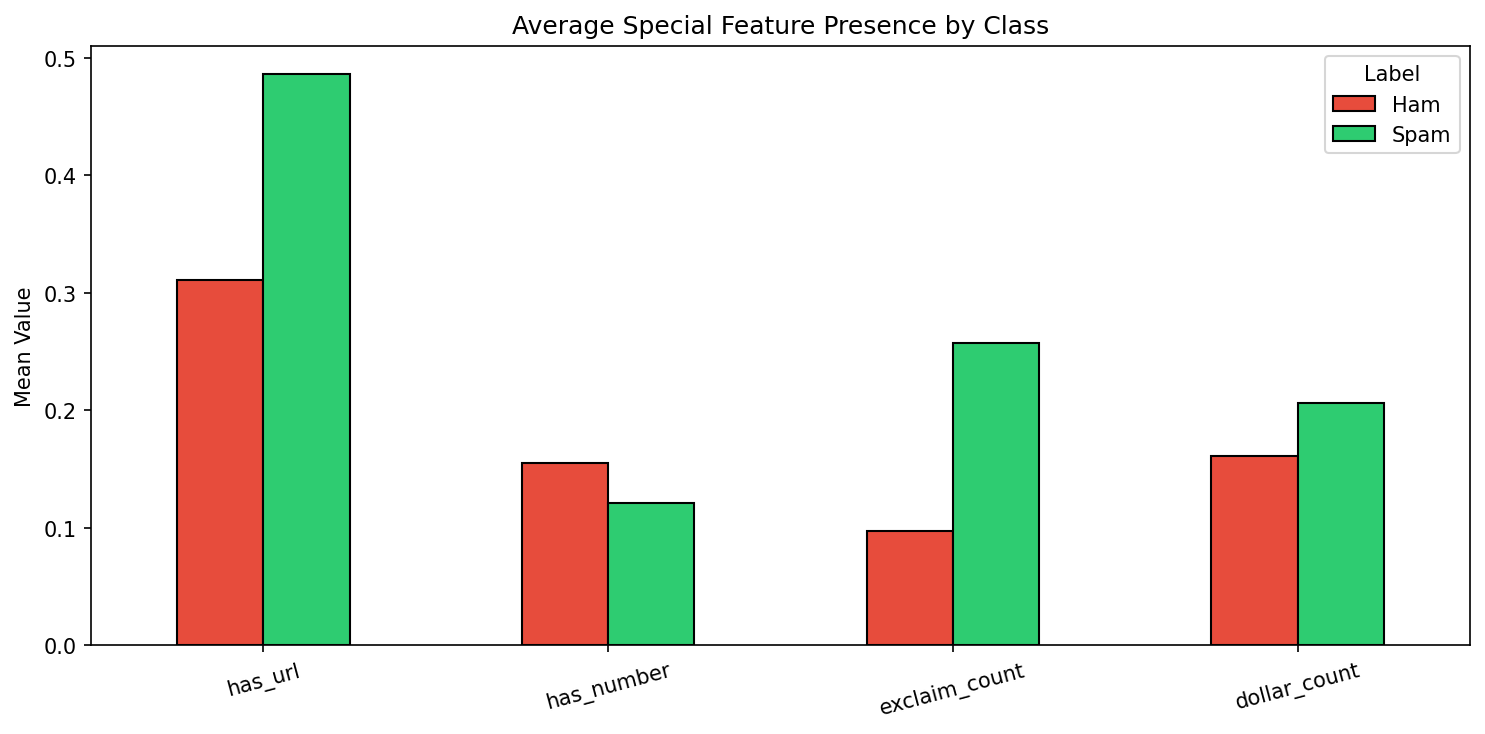

In [ ]:
# Special characters & URL patterns
# Spam emails often contain URLs, excessive punctuation, and numbers as tactics to evade filters.

df["has_url"]        = df["text"].str.contains(r"http|www|\.com", case=False, regex=True).astype(int)
df["has_number"]     = df["text"].str.contains(r"\d", regex=True).astype(int)
df["exclaim_count"]  = df["text"].str.count(r"!")
df["dollar_count"]   = df["text"].str.count(r"\$")

features = ["has_url", "has_number", "exclaim_count", "dollar_count"]
summary  = df.groupby("label")[features].mean().round(3)
print(summary)

summary.T.plot(kind="bar", figsize=(10, 5), color=["#e74c3c", "#2ecc71"],
               edgecolor="black")
plt.title("Average Special Feature Presence by Class")
plt.ylabel("Mean Value")
plt.xticks(rotation=15)
plt.legend(title="Label")
plt.tight_layout()
plt.savefig(os.path.join(EDA_PLOT_DIR, "special_features.png"))
plt.show()

## EDA Findings

The dataset exhibits a near-balanced class distribution, with approximately 53% spam emails and 47% ham emails. As a result, class imbalance is not expected to significantly impact model training.

Analysis of email lengths shows that ham emails are generally longer than spam emails, with average lengths of 334 and 210 words respectively. This is likely because ham emails contain complete workplace conversations and email threads, while spam emails tend to be concise and promotional. Several extreme outliers were identified within the ham class, including emails exceeding 1.5 million words, which are likely corrupted records and will be removed during preprocessing.

Word frequency analysis and word clouds revealed that the token *escapenumber* is highly prevalent in both classes, indicating that masked numerical values are common but not particularly informative for classification. More meaningful patterns emerge beneath this token. Spam emails frequently contain words related to marketing and pharmaceutical promotions, while ham emails are dominated by terms associated with corporate communication and email forwarding.

Bigram analysis further highlights the differences between the classes. Common spam phrases are typically associated with URLs, pricing information, and product promotions. In contrast, ham emails frequently contain phrases related to workplace correspondence and forwarded message chains.

Several handcrafted features were also examined. Spam emails are more likely to contain URLs, exclamation marks, and dollar signs than ham emails. Among these, the presence of URLs and elevated use of exclamation marks appear to be the strongest indicators of spam and will therefore be included as additional features alongside TF-IDF representations during model training.

One limitation of the dataset is that it primarily consists of commercial or pharmaceutical spam and corporate ham emails derived from the Enron email corpus. Consequently, the model may learn patterns specific to Enron-style workplace communication rather than fully generalisable characteristics of legitimate email, which could reduce performance when applied to different email domains.
